In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

<font size="20" color="red">ch11.데이터 프래임과 시리즈(Pandas)</font>
# 9절. 데이터 그룹화 및 집계

In [4]:
from statsmodels.api import datasets
iris = datasets.get_rdataset('iris').data
iris.iloc[[0,49,50,99,100,149]]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
49,5.0,3.3,1.4,0.2,setosa
50,7.0,3.2,4.7,1.4,versicolor
99,5.7,2.8,4.1,1.3,versicolor
100,6.3,3.3,6.0,2.5,virginica
149,5.9,3.0,5.1,1.8,virginica


## 9.1 Group by
    cf.pivot_table

In [5]:
iris.groupby('Species').sum()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,250.3,171.4,73.1,12.3
versicolor,296.8,138.5,213.0,66.3
virginica,329.4,148.7,277.6,101.3


In [6]:
# 1) 그룹화방법 1
#     df.groupby(by=[그룹핑할열이름])[함수적용해서출력할열들].기초통계함수()
#     [함수적용해서출력할열들] 생략시 모든열이 적용
iris_grouped = iris.groupby('Species')
iris_grouped = iris.groupby(iris.Species)
iris_grouped_sum = iris_grouped.sum()
iris_grouped_sum    #iris.groupby('Species').sum()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,250.3,171.4,73.1,12.3
versicolor,296.8,138.5,213.0,66.3
virginica,329.4,148.7,277.6,101.3


In [7]:
# setosa, virginica 의 집계만
iris_grouped_sum.loc[['setosa','virginica']]


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,250.3,171.4,73.1,12.3
virginica,329.4,148.7,277.6,101.3


In [8]:
print(iris_grouped_sum.index)

Index(['setosa', 'versicolor', 'virginica'], dtype='object', name='Species')


In [9]:
iris_grouped_sum.reset_index(inplace=True) #인덱스를 컬럼으로 편입시킴

In [10]:
iris_grouped_sum

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
1,versicolor,296.8,138.5,213.0,66.3
2,virginica,329.4,148.7,277.6,101.3


In [390]:
# setosa, virginica 의 집계만
iris_grouped_sum[(iris_grouped_sum.Species=='setosa')|(iris_grouped_sum.Species=='virginica')]
iris_grouped_sum[iris_grouped_sum.Species.isin(['setosa','virginica'])]

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
2,virginica,329.4,148.7,277.6,101.3


In [ ]:
# 1) 그룹화방법 1-1: 그룹핑할때 index를 컬럼 데이터로 편입(reset_index()가 필요 없음) 
#     df.groupby(by=[그룹핑할열이름])as_index=False[함수적용해서출력할열들].기초통계함수()
#     [함수적용해서출력할열들] 생략시 모든열이 적용

iris.groupby(iris['Species'],as_index=False).sum
iris.groupby(iris.Species, as_index=False).sum
iris.groupby('Species',as_index=False).sum

In [ ]:
iris.groupby('Species', as_index=False).sum()

In [ ]:
iris.groupby(iris['Species'], as_index=False).sum()

In [ ]:
#종별 Sepal.Length와 Sepal.Width의 평균
iris.groupby('Species').mean()[['Sepal.Length','Sepal.Width']]
iris.groupby('Species').mean()[['Sepal.Length','Sepal.Width']]

In [ ]:
#종별Sepal.Length의 합계
iris.groupby('Species')['Sepal.Length'].sum()# 결과가 시리즈 1차원

In [ ]:
#종별Sepal.Length의 합계
iris.groupby('Species')['Sepal.Length',].sum()
iris.groupby('Species')[['Sepal.Length']].sum()# 결과가 시리즈 1차원

In [15]:
# 그룹화방법 1
#      df.groupby(by=[그룹필열이름들],as_index=T/F)[함수적용해서출력할열들].함수명()
# 그룹화방법 2
#      df.pivot_table(index='그룹핑할이름들',
#                    values='함수적용해서출력할열들',
#                     aggfunc=함수명(기본값:mean)
#                     )
#pd.pivot_table(df,index,values,aggfunc)

g=iris.pivot_table(index='Species',
                # values=['Sepal.Length','Sepal.Width','Petal.Length','Petal.Width']
                # aggfunc='mean'
                )
g

,Petal.Length,Petal.Width,Sepal.Length,Sepal.Width
Species,,,,
setosa,1.462,0.246,5.006,3.428
versicolor,4.260,1.326,5.936,2.770
virginica,5.552,2.026,6.588,2.974


In [16]:
iris.groupby('Species').mean()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


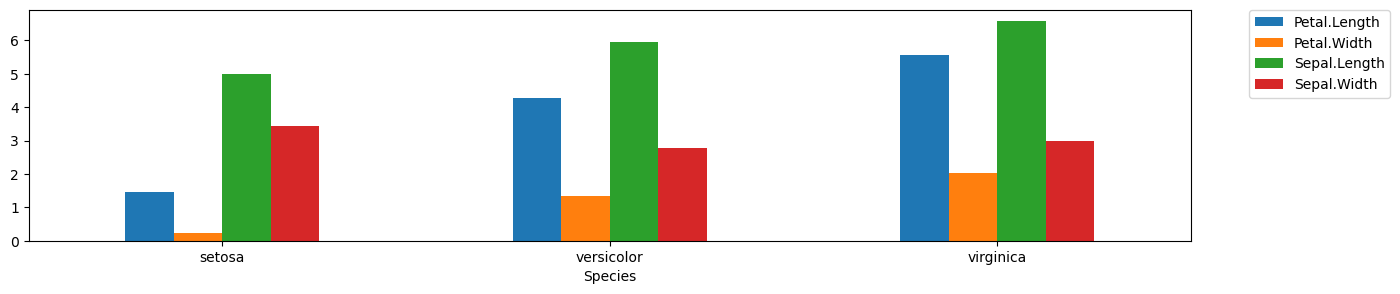

In [17]:
#범례를 밖으로 : 시각화 20page.판다스60page.
import matplotlib.pyplot as plt
g.plot(kind='bar',figsize=(15,3),rot=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

In [18]:
iris.pivot_table(index='Species',values='Sepal.Length',aggfunc='count')
iris.groupby('Species')['Sepal.Length'].count()
iris['Species'].value_counts()#정렬까지

setosa        50
versicolor    50
virginica     50
Name: Species, dtype: int64

In [19]:
#임의로 각열마다 결측치를 할당(0번째 열은 결측치1/1번째 열은 결측치2/2번쨰 열은 결측치3/3번째 열은 결측치4)
import numpy as np
import random
# random.sample(range(0,150),2)
for col in range(iris.shape[1]-1):
    rows = random.sample(range(len(iris)),col+1)
    iris.iloc[rows,col] = np.nan

In [20]:
# 열별 결측치를 제외한 데이터 갯수
# iris.isna().sum()
iris.groupby('Species').count()
iris.pivot_table(index='Species',aggfunc='count')

,Petal.Length,Petal.Width,Sepal.Length,Sepal.Width
Species,,,,
setosa,48,48,50,49
versicolor,50,48,50,49
virginica,49,50,49,50


### 다중열로 그룹화

In [21]:
iris.head(1)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa


In [22]:
# iris로 다중열 그룹화 하기위해 데이터 추가(num 컬럼 )
# iris 행수는 150개 =Species 3그룹,num 6그룹
iris['num']=np.array([[i]*25 for i in range(6)]).flatten()
iris.iloc[::25]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species,num
0,5.1,3.5,1.4,0.2,setosa,0
25,5.0,3.0,1.6,0.2,setosa,1
50,7.0,3.2,4.7,1.4,versicolor,2
75,6.6,3.0,4.4,1.4,versicolor,3
100,6.3,3.3,6.0,2.5,virginica,4
125,7.2,3.2,6.0,1.8,virginica,5


In [23]:
# 종별,num별 합계
r=iris.groupby(['Species','num']).sum()
r

Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
Species    num                                                      
setosa     0           125.7         87.0          36.5          5.8
           1           124.6         80.9          34.0          6.1
versicolor 2           150.3         69.4         107.8         32.6
           3           146.5         66.0         105.2         31.1
virginica  4           157.7         73.2         141.0         51.1
           5           165.0         75.5         130.5         50.2

In [24]:
r.loc[['setosa','virginica']]

Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
Species   num                                                      
setosa    0           125.7         87.0          36.5          5.8
          1           124.6         80.9          34.0          6.1
virginica 4           157.7         73.2         141.0         51.1
          5           165.0         75.5         130.5         50.2

In [25]:
r.loc[[('setosa',0),('virginica',5)]] # num이 0과 5인 합계만

,,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,num,,,,
setosa,0,125.7,87.0,36.5,5.8
virginica,5,165.0,75.5,130.5,50.2


In [26]:
# 종별,num별 합계
iris.pivot_table(index=['Species','num'])

Petal.Length  Petal.Width  Sepal.Length  Sepal.Width
Species    num                                                      
setosa     0        1.460000     0.252174      5.028000     3.480000
           1        1.478261     0.244000      4.984000     3.370833
versicolor 2        4.312000     1.358333      6.012000     2.776000
           3        4.208000     1.295833      5.860000     2.750000
virginica  4        5.640000     2.044000      6.570833     2.928000
           5        5.437500     2.008000      6.600000     3.020000

In [27]:
# 종별 기초통계량들
iris.groupby(['Species']).describe().T

Species                setosa  versicolor  virginica
Sepal.Length count  50.000000   50.000000  49.000000
             mean    5.006000    5.936000   6.585714
             std     0.352490    0.516171   0.642262
             min     4.300000    4.900000   4.900000
             25%     4.800000    5.600000   6.200000
             50%     5.000000    5.900000   6.500000
             75%     5.200000    6.300000   6.900000
             max     5.800000    7.000000   7.900000
Sepal.Width  count  49.000000   49.000000  50.000000
             mean    3.426531    2.763265   2.974000
             std     0.382849    0.313378   0.322497
             min     2.300000    2.000000   2.200000
             25%     3.200000    2.500000   2.800000
             50%     3.400000    2.800000   3.000000
             75%     3.700000    3.000000   3.175000
             max     4.400000    3.400000   3.800000
Petal.Length count  48.000000   50.000000  49.000000
             mean    1.468750    4.260000   5.540816
             std     0.174009    0.469911   0.551860
             min     1.000000    3.000000   4.500000
             25%     1.400000    4.000000   5.100000
             50%     1.500000    4.350000   5.500000
             75%     1.600000    4.600000   5.800000
             max     1.900000    5.100000   6.900000
Petal.Width  count  48.000000   48.000000  50.000000
             mean    0.247917    1.327083   2.026000
             std     0.107168    0.192121   0.274650
             min     0.100000    1.000000   1.400000
             25%     0.200000    1.200000   1.800000
             50%     0.200000    1.300000   2.000000
             75%     0.300000    1.500000   2.300000
             max     0.600000    1.800000   2.500000
num          count  50.000000   50.000000  50.000000
             mean    0.500000    2.500000   4.500000
             std     0.505076    0.505076   0.505076
             min     0.000000    2.000000   4.000000
             25%     0.000000    2.000000   4.000000
             50%     0.500000    2.500000   4.500000
             75%     1.000000    3.000000   5.000000
             max     1.000000    3.000000   5.000000

## 9.2 그룹간 데이터 처리

In [28]:
from statsmodels.api import datasets
iris = datasets.get_rdataset('iris').data
iris.head(1)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa


In [29]:
iris_grouped = iris.groupby('Species')
iris_grouped

In [33]:
#종별 상위 5행 출력
for speciesname, group in iris_grouped:
    print(speciesname)
    display(group.head())

setosa


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa


versicolor


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
50,7.0,3.2,4.7,1.4,versicolor
51,6.4,3.2,4.5,1.5,versicolor
52,6.9,3.1,4.9,1.5,versicolor


virginica


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
100,6.3,3.3,6.0,2.5,virginica
101,5.8,2.7,5.1,1.9,virginica
102,7.1,3.0,5.9,2.1,virginica


In [39]:
#종별 임의의 표본 3행 출력
for speciesname, group in iris_grouped:
    print(speciesname)
    display(group.sample(3).sort_index())#.reset_index(drop=True))

setosa


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
22,4.6,3.6,1.0,0.2,setosa
26,5.0,3.4,1.6,0.4,setosa
36,5.5,3.5,1.3,0.2,setosa


versicolor


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
55,5.7,2.8,4.5,1.3,versicolor
59,5.2,2.7,3.9,1.4,versicolor
82,5.8,2.7,3.9,1.2,versicolor


virginica


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
131,7.9,3.8,6.4,2.0,virginica
132,6.4,2.8,5.6,2.2,virginica
137,6.4,3.1,5.5,1.8,virginica


In [40]:
#종별 0,15,30,45번째행 출력
for speciesname, group in iris_grouped:
    print(speciesname)
    display(group.iloc[[0,15,30,45]])

setosa


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
15,5.7,4.4,1.5,0.4,setosa
30,4.8,3.1,1.6,0.2,setosa
45,4.8,3.0,1.4,0.3,setosa


versicolor


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
50,7.0,3.2,4.7,1.4,versicolor
65,6.7,3.1,4.4,1.4,versicolor
80,5.5,2.4,3.8,1.1,versicolor
95,5.7,3.0,4.2,1.2,versicolor


virginica


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
100,6.3,3.3,6.0,2.5,virginica
115,6.4,3.2,5.3,2.3,virginica
130,7.4,2.8,6.1,1.9,virginica
145,6.7,3.0,5.2,2.3,virginica


## 9.3 데이터 프래임 그룹별 인덱싱

In [41]:
#종별 0,15,30,45번째행 출력
# for speciesname, group in iris_grouped:
#     print(speciesname)
#     display(group.iloc[[0,15,30,45]])
iris.groupby('Species').take([0,15,30,45])
r

setosa


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
15,5.7,4.4,1.5,0.4,setosa
30,4.8,3.1,1.6,0.2,setosa
45,4.8,3.0,1.4,0.3,setosa


versicolor


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
50,7.0,3.2,4.7,1.4,versicolor
65,6.7,3.1,4.4,1.4,versicolor
80,5.5,2.4,3.8,1.1,versicolor
95,5.7,3.0,4.2,1.2,versicolor


virginica


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
100,6.3,3.3,6.0,2.5,virginica
115,6.4,3.2,5.3,2.3,virginica
130,7.4,2.8,6.1,1.9,virginica
145,6.7,3.0,5.2,2.3,virginica


Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
Species    num                                                      
setosa     0           125.7         87.0          36.5          5.8
           1           124.6         80.9          34.0          6.1
versicolor 2           150.3         69.4         107.8         32.6
           3           146.5         66.0         105.2         31.1
virginica  4           157.7         73.2         141.0         51.1
           5           165.0         75.5         130.5         50.2

# 10절. 데이터 구조 변경
- 와이드 포맷<--->롱포맷(tidy data)
- 판다스 공식 문서에 나오는 melt :https://pandas.pydata.org/docs/user_guide/reshaping.html#melt-and-wide-to-long
- Tidy Data : https://vita.had.co.nz/papers/tidy-data.pdf

In [42]:
from statsmodels.api import datasets
airquality = datasets.get_rdataset('airquality').data #1973년 뉴욕 공기질 데이터 셋
airquality

,Ozone,Solar.R,Wind,Temp,Month,Day
0,41.0,190.0,7.4,67,5,1
1,36.0,118.0,8.0,72,5,2
2,12.0,149.0,12.6,74,5,3
3,18.0,313.0,11.5,62,5,4
4,NaN,NaN,14.3,56,5,5
...,...,...,...,...,...,...
148,30.0,193.0,6.9,70,9,26
149,NaN,145.0,13.2,77,9,27
150,14.0,191.0,14.3,75,9,28
151,18.0,131.0,8.0,76,9,29


## 10.1 melt를 이용한 언피벗팅(와이드 포멧 →롱포맷)
- df.melt(id_vars, value_vars, var_name, value_name)
- pd.melt(df,id_vars, value_vars, var_name, value_name)

In [52]:
# pd.melt(airquality,id_vars=['Month','Day'])
airquality_melted=airquality.melt(id_vars=['Month','Day'],
                                 #value_vars=['Ozone','Solar.R','Wind','Temp']melt될 열이름
                                 )
airquality_melted

,Month,Day,variable,value
0,5,1,Ozone,41.0
1,5,2,Ozone,36.0
2,5,3,Ozone,12.0
3,5,4,Ozone,18.0
4,5,5,Ozone,NaN
...,...,...,...,...
607,9,26,Temp,70.0
608,9,27,Temp,77.0
609,9,28,Temp,75.0
610,9,29,Temp,76.0


In [60]:
airquality_melted = airquality.melt(id_vars=['Month','Day'],
                                   var_name='변수명',#melt된 데이터의 열이름
                                   value_name='값') # 데이터가 된 열이름
airquality_melted = airquality_melted.sort_values(by=['Month','Day']).reset_index(drop=True)
airquality_melted

,Month,Day,변수명,값
0,5,1,Ozone,41.0
1,5,1,Solar.R,190.0
2,5,1,Wind,7.4
3,5,1,Temp,67.0
4,5,2,Ozone,36.0
...,...,...,...,...
607,9,29,Temp,76.0
608,9,30,Ozone,20.0
609,9,30,Solar.R,223.0
610,9,30,Wind,11.5


## 10.2 pivot_table을 이용한 피벗팅(롱포맷→와이드 포맷)
- df.pivot_table(index,columns,values)
- pd.pivot_table(df,index,columns,values)

In [69]:
# pd.pivot_table(airquality_melted,index=['Month','Day'],columns='변수명',values='값')
airquality2=airquality_melted.pivot_table(index=['Month','Day'],
                             columns='변수명',
                             #values='값'
                                         )
airquality2.columns=airquality2.columns.droplevel(level=0)
airquality2=airquality2.reset_index()
airquality2

변수명,Month,Day,Ozone,Solar.R,Temp,Wind
0,5,1,41.0,190.0,67.0,7.4
1,5,2,36.0,118.0,72.0,8.0
2,5,3,12.0,149.0,74.0,12.6
3,5,4,18.0,313.0,62.0,11.5
4,5,5,NaN,NaN,56.0,14.3
...,...,...,...,...,...,...
148,9,26,30.0,193.0,70.0,6.9
149,9,27,NaN,145.0,77.0,13.2
150,9,28,14.0,191.0,75.0,14.3
151,9,29,18.0,131.0,76.0,8.0


# 11절. 데이터프레임에 함수 적용시키기
- apply(func,axis) : 데이터 프래임이나 시리즈 모두 적용가능
- map(func) : 각 요소별로 func적용(1차원 시리즈에서만 가능)
- applymap(func) : 각 요소별로 func 적용(데이터 프래임에서만 가능)

## 11.1 apply / map

In [70]:
# ex1. 1차원 시리즈에 apply / map 이용
import pandas as pd
member = pd.read_csv('data/ch11_member.csv',comment='#')
member.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Name     5 non-null      object
 1   Age      5 non-null      int64 
 2   Email    5 non-null      object
 3   Address  5 non-null      object
 4   Birth    5 non-null      object
dtypes: int64(1), object(4)
memory usage: 328.0+ bytes


In [77]:
def get_year(datestr):
    print(datestr.split('-')[0])
get_year=lambda datestr : int(datestr.split('-')[0])
get_year("1999-01-01")

1999

In [79]:
def get_month(x):
    print(x.split('-')[0])
get_year=lambda x : int(x.split('-')[1])
get_year("1999-01-01")

1

In [81]:
member['년']=member['Birth'].map(lambda datestr : int(datestr.split('-')[0]))
member['월']=member['Birth'].map(lambda x : int(x.split('-')[1]))
member

,Name,Age,Email,Address,Birth,년,월
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01,1999,1
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01,1999,12
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01,1999,11
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01,1999,5
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30,1999,1


In [139]:
# ex2. 2차원 데이터 프래임에서 apply(func,axis=1)
%ls "C:\ai\downloads\shareData\분양가격"

 C 드라이브의 볼륨에는 이름이 없습니다.
 볼륨 일련 번호: 0C81-36F7

 C:\ai\downloads\shareData\분양가격 디렉터리

2026-07-14  오후 05:38    <DIR>          .
2026-07-14  오후 05:39    <DIR>          ..
2026-06-24  오후 10:04             2,163 전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv
2026-07-14  오후 05:35           501,367 주택도시보증공사_전국 신규 민간아파트 분양가격 동향_20260531.csv
               2개 파일             503,530 바이트
               2개 디렉터리  148,473,901,056 바이트 남음


In [140]:
df_last = pd.read_csv(r'C:/ai/downloads/shareData/분양가격/주택도시보증공사_전국 신규 민간아파트 분양가격 동향_20260531.csv',
                     encoding='cp949')
df_last.head(2)

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원)
0,서울,모든면적,2015,10,5841
1,서울,전용면적 60제곱미터이하,2015,10,5652


In [141]:
df_last.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10880 entries, 0 to 10879
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   지역명             10880 non-null  object
 1   규모구분            10880 non-null  object
 2   연도              10880 non-null  int64 
 3   월               10880 non-null  int64 
 4   분양가격(제곱미터당 천원)  10035 non-null  object
dtypes: int64(2), object(3)
memory usage: 425.1+ KB


In [142]:
def year_month(series):
     return"{}-{:02}".format(series['연도'],series['월'])        
year_month(df_last.loc[300])

'2016-01'

In [143]:
df_last['연도월'] = \
        df_last.apply(lambda series :"{}-{:02}".format(series['연도'],series['월']),axis=1)
df_last.tail()

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원),연도월
10875,제주,모든면적,2026,5,4473,2026-05
10876,제주,전용면적 60제곱미터이하,2026,5,NaN,2026-05
10877,제주,전용면적 60제곱미터초과 85제곱미터이하,2026,5,4485,2026-05
10878,제주,전용면적 85제곱미터초과 102제곱미터이하,2026,5,NaN,2026-05
10879,제주,전용면적 102제곱미터초과,2026,5,4350,2026-05


In [144]:
# ex3. 2차원에서의 apply(func,axis=0)


In [145]:
import numpy as np
X = iris.iloc[:,:-1]
avg = np.mean(iris.iloc[:,:-1],axis=0)
avg = iris.iloc[:,:-1].mean(axis=0)#열별평균
avg

Sepal.Length    5.843333
Sepal.Width     3.057333
Petal.Length    3.758000
Petal.Width     1.199333
dtype: float64

In [146]:
# 각 열별 평균과의 거리를 출력
X.apply(lambda x:round(x-avg,2),axis=1)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,-0.74,0.44,-2.36,-1.0
1,-0.94,-0.06,-2.36,-1.0
2,-1.14,0.14,-2.46,-1.0
3,-1.24,0.04,-2.26,-1.0
4,-0.84,0.54,-2.36,-1.0
...,...,...,...,...
145,0.86,-0.06,1.44,1.1
146,0.46,-0.56,1.24,0.7
147,0.66,-0.06,1.44,0.8
148,0.36,0.34,1.64,1.1


## 11.2 applymap

In [147]:
X.applymap(lambda x: round(x,3))

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


※ melt()및 함수 적용시키기 연습예제(분양가격 csv 두파일 통합)
- 와이드 포맷 →롱포맷(melt) : 2013~2015년 데이터
- 평당 분양가격/3.3 => 분양가격(제곱미터당 천원)
- 2013년 12월 -> 2013과 12을 나눠 '연도'와 '월'컬럼(apply,map)
    =>new_first
 - df_last['규모구분']=='모든면적' 데이터만 추출(지역, 연도, 월, 분양가격(제곱미터당 천원)컬럼만)
 - df_last의 지역명 컬럼명을 지역으로 변경
     =>new_last
 - pd.concat([new_first,new_last])

In [148]:
df_last.head(1)

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원),연도월
0,서울,모든면적,2015,10,5841,2015-10


In [149]:
df_first = pd.read_csv(r'C:\ai\downloads\shareData\분양가격\전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv',
                      encoding='cp949')
df_first.head(1)

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,...,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
0,서울,18189,17925,17925,18016,18098,19446,18867,18742,19274,...,20242,20269,20670,20670,19415,18842,18367,18374,18152,18443


In [150]:
# 와이드포맷->롱포맷
new_first=df_first.melt(id_vars='지역',var_name='연도월',value_name='평당분양가격')
new_first.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   지역      357 non-null    object
 1   연도월     357 non-null    object
 2   평당분양가격  357 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 8.5+ KB


In [151]:
# 평당분양가격/3.3
new_first['분양가격(제곱미터당 천원)'] = new_first['평당분양가격']/3.3
new_first.head()

,지역,연도월,평당분양가격,분양가격(제곱미터당 천원)
0,서울,2013년12월,18189,5511.818182
1,부산,2013년12월,8111,2457.878788
2,대구,2013년12월,8080,2448.484848
3,인천,2013년12월,10204,3092.121212
4,광주,2013년12월,6098,1847.878788


In [152]:
# 2013년 12월 => 2013년 12을 나눠 '연도'와 '월'컬럼(apply,map)
def parse_year(datestr):
    return int(datestr.split('년')[0])
(lambda datestr : int(datestr.split('년')[0]))("2013년12월")
def parse_month(datestr):
    return datestr.split('년')[1][:-1]
parse_month("2013년12월")

'12'

In [154]:
new_first['연도'] = new_first['연도월'].map(lambda datestr : int(datestr.split('년')[0]))
new_first['월'] = new_first['연도월'].map(lambda datestr : int(datestr.split('년')[1][:-1]))
new_first.drop(['연도월','평당분양가격'],axis=1,inplace=True) #불필요한 컬럼 drop
new_first.head(1)

,지역,분양가격(제곱미터당 천원),연도,월
0,서울,5511.818182,2013,12


In [155]:
df_last.head()

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원),연도월
0,서울,모든면적,2015,10,5841,2015-10
1,서울,전용면적 60제곱미터이하,2015,10,5652,2015-10
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882,2015-10
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721,2015-10
4,서울,전용면적 102제곱미터초과,2015,10,5879,2015-10


In [160]:
#df_last['규모구분']=='모든면적' 데이터만 추출(지역, 연도, 월, 분양가격(제곱미터당 천원)컬럼만)
new_last = df_last.loc[df_last['규모구분']=='모든면적',['지역명','연도','월','분양가격(제곱미터당 천원)']]
# 지역명 컬럼명을 지역으로 변경 =>new_last
# new_last.columns = ['지역','연도','월','분양가격(제곱미터당 천원)']
new_last.rename(columns={'지역명':'지역'},inplace=True)#지역명 컬럼명을 지역으로 변경
new_last.head(1)

,지역,연도,월,분양가격(제곱미터당 천원)
0,서울,2015,10,5841


In [164]:
# concat
df = pd.concat([new_first,new_last],
               #axis=0
              ).reset_index(drop=True)#같은 컬럼명 기준으로 행 연결
df.loc[[0,10,20]]

,지역,분양가격(제곱미터당 천원),연도,월
0,서울,5511.818182,2013,12
10,충북,1996.666667,2013,12
20,인천,3092.121212,2014,1


# 12절. 일괄변경하기(결측치나 특정값)
## 12.1 fillna(결측치를 어떤값으로 대체)
- 대부분의 결측치는 drop하거나, 평균값대체, 중위수(중앙값,2사분위수)대체, 최빈값대체,이전값, 다음값, 그룹별 평균값으로 대체

In [166]:
df = pd.DataFrame([[np.nan,2,np.nan,0],
                  [3,     4,np.nan,1],
                  [np.nan,3,np.nan,5],
                  [np.nan,3,np.nan,4]],columns=list('ABCD'))
df

,A,B,C,D
0,NaN,2,NaN,0
1,3.0,4,NaN,1
2,NaN,3,NaN,5
3,NaN,3,NaN,4


In [167]:
# 모든 결측치를 무조건 0으로 대체
df.fillna(0)

,A,B,C,D
0,0.0,2,0.0,0
1,3.0,4,0.0,1
2,0.0,3,0.0,5
3,0.0,3,0.0,4


In [168]:
# 결측치를 이전행의 값으로 대체
df.fillna(method='ffill')

,A,B,C,D
0,NaN,2,NaN,0
1,3.0,4,NaN,1
2,3.0,3,NaN,5
3,3.0,3,NaN,4


In [169]:
# 결측치를 다음행의 값으로 대체
df.fillna(method='bfill')

,A,B,C,D
0,3.0,2,NaN,0
1,3.0,4,NaN,1
2,NaN,3,NaN,5
3,NaN,3,NaN,4


In [172]:
#결측치를 열마다 특정값으로 대체
values = {'A':99,'B':98,'C':97,'D':96}
df.fillna(value=values)

,A,B,C,D
0,99.0,2,97.0,0
1,3.0,4,97.0,1
2,99.0,3,97.0,5
3,99.0,3,97.0,4


In [173]:
#결측치를 각 열의 평균값으로 대체(결측치 대체는 2번째 까지만)
df.mean(axis=0)
df.fillna(value=df.mean(axis=0),limit=2)

,A,B,C,D
0,3.0,2,NaN,0
1,3.0,4,NaN,1
2,3.0,3,NaN,5
3,NaN,3,NaN,4


In [175]:
#결측치를 각 열의 중위수(중앙값)으로 대체
df.fillna(value=df.median(axis=0))

,A,B,C,D
0,3.0,2,NaN,0
1,3.0,4,NaN,1
2,3.0,3,NaN,5
3,3.0,3,NaN,4


In [178]:
#결측치를 각열의 최빈값으로 대체
df.fillna(df.mode().loc[0])

A    3.0
B    3.0
C    NaN
D    0.0
Name: 0, dtype: float64

## 12.2 replace(to_value,new_value,inplace=T/F)
- to_value를 new_value로 변경
- to_value에는 정규표현식 이용가능

In [183]:
s = pd.Series([0,1,2,3,None])
s.replace(np.nan,0,inplace=True)
s.replace([0,1],99) #0이나 1을 99로 변경

0    99.0
1    99.0
2     2.0
3     3.0
4    99.0
dtype: float64

In [184]:
s = pd.Series([0,1,2,3,None])
s.replace([0,1,2],[100,101,102])

0    100.0
1    101.0
2    102.0
3      3.0
4      NaN
dtype: float64

In [186]:
df = pd.DataFrame({'A':['bat','foo','bait'],
                   'B':['abc','bat','xvy']})
df

,A,B
0,bat,abc
1,foo,bat
2,bait,xvy


In [193]:
df.replace('ba.+','xx',regex=True)
df.replace('^ba.+$','xx',regex=True)
df.replace(regex='ba.+',value='xx')
df.replace(regex=['ba.+','fo.'],value='xx')

,A,B
0,xx,abc
1,xx,xx
2,xx,xvy


In [194]:
df.replace({'A':'bat','B':'abc'},'xx')

,A,B
0,xx,xx
1,foo,bat
2,bait,xvy


## 12.3 where(조건),mask(조건)

In [196]:
# 넘파이 where
a = np.array([1,2,3,4,5,6])
np.where(a>3)

(array([3, 4, 5], dtype=int64),)

In [197]:
s = pd.Series(range(10,20))
s

0    10
1    11
2    12
3    13
4    14
5    15
6    16
7    17
8    18
9    19
dtype: int64

In [198]:
#15이상
s[s>=15]

5    15
6    16
7    17
8    18
9    19
dtype: int64

In [199]:
s.where(s>=15) #조건이 만족되는 데이터는 그대로 출력. 만족되지않는 데이터는 결측치

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
5    15.0
6    16.0
7    17.0
8    18.0
9    19.0
dtype: float64

In [200]:
s.where(s>=15,other=-1) #조건이 만족되는 데이터는 그대로 출력. 만족되지않는 데이터는 -1

0    -1
1    -1
2    -1
3    -1
4    -1
5    15
6    16
7    17
8    18
9    19
dtype: int64

In [201]:
s.mask(s>=15) # 조건이 만족되는 데이터만 결측치

0    10.0
1    11.0
2    12.0
3    13.0
4    14.0
5     NaN
6     NaN
7     NaN
8     NaN
9     NaN
dtype: float64

## 12.4 dropna
- 결측치가 있는 데이터 누락(행기준,열기준)

In [203]:
df = pd.DataFrame({'name':['홍','김',np.nan,np.nan],
                  'age':[np.nan,20,30,np.nan],
                  'born':['서울','부산',np.nan,np.nan]})
df

,name,age,born
0,홍,NaN,서울
1,김,20.0,부산
2,NaN,30.0,NaN
3,NaN,NaN,NaN


In [204]:
df.dropna(#axis=0
         ) # 결측치가 하나라도 있는행을 drop,inplace=True가 아니면 return

,name,age,born
1,김,20.0,부산


In [205]:
df.dropna(thresh=2)#결측치가 아닌값이 2개 이상이면 drop 안함

,name,age,born
0,홍,NaN,서울
1,김,20.0,부산


In [208]:
df.dropna(subset=['name','born'])#name열과 born열에 결측치가 하나라도 있는 행 drop

,name,age,born
0,홍,NaN,서울
1,김,20.0,부산


In [210]:
df.dropna(how='all')# 모두 결측치인 행 drop

,name,age,born
0,홍,NaN,서울
1,김,20.0,부산
2,NaN,30.0,NaN


In [211]:
df.dropna(axis=1)# 결측치가 하나라도 있는 열은 drop

""
0
1
2
3


In [212]:
df.dropna(axis=1,how='all')# 결측치가 하나라도 있는 열은 drop

,name,age,born
0,홍,NaN,서울
1,김,20.0,부산
2,NaN,30.0,NaN
3,NaN,NaN,NaN


### ※ iris결측치를 열별 평균으로 대체(교안 80p:fillna)

In [277]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.head(1)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa


In [278]:
iris.isna().sum()# 열마다 결측치 갯수
iris.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [279]:
iris.notna().sum()# 열마다 결측치를 제외한 갯수
iris.notnull().sum()

sepal_length    150
sepal_width     150
petal_length    150
petal_width     150
species         150
dtype: int64

In [280]:
#1단계 : iris 데이터에서 결측치를 인위적으로 random하게 열 마다 20씩 결측치를 할당한다
import random
print(random.sample(range(iris.shape[0]),20))

[111, 13, 12, 25, 61, 95, 47, 78, 62, 109, 44, 113, 54, 96, 38, 135, 143, 89, 122, 103]


In [281]:
for col in range(iris.shape[1]-1):
    randomidx = random.sample(range(iris.shape[0]),20)
    #print(col,randomidx)
    iris.iloc[randomidx,col] = np.nan
iris.isna().sum()

sepal_length    20
sepal_width     20
petal_length    20
petal_width     20
species          0
dtype: int64

In [282]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,NaN,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [283]:
# 2단계 : 결측치가 있는 iris데이터를 출력한다
iris[iris['sepal_length'].isna()|iris['sepal_width'].isna()|
     iris['petal_width'].isnull() | iris['petal_length'].isnull()]

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,NaN,1.4,0.2,setosa
5,5.4,NaN,1.7,0.4,setosa
7,5.0,3.4,1.5,NaN,setosa
8,4.4,NaN,1.4,0.2,setosa
9,4.9,NaN,1.5,0.1,setosa
...,...,...,...,...,...
141,NaN,3.1,5.1,2.3,virginica
143,NaN,3.2,5.9,2.3,virginica
144,6.7,NaN,5.7,2.5,virginica
147,6.5,3.0,NaN,2.0,virginica


In [284]:
# 3단계 : 결측치를 열평균으로 대체된 iris데이터를 출력한다
iris.iloc[:,:-1].mean(axis=0)
iris.mean(axis=0,numeric_only=True)
iris_fillna=iris.fillna(value=iris.iloc[:,:-1].mean(axis=0))
iris_fillna.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [285]:
# 소숫점 3자리에서 반올림
iris_fillna.iloc[:,:-1]=iris_fillna.iloc[:,:-1].applymap(lambda x : np.round(x,3))
iris_fillna

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.032,1.400,0.200,setosa
1,4.9,3.000,1.400,0.200,setosa
2,4.7,3.200,1.300,0.200,setosa
3,4.6,3.100,1.500,0.200,setosa
4,5.0,3.600,1.400,0.200,setosa
...,...,...,...,...,...
145,6.7,3.000,5.200,2.300,virginica
146,6.3,2.500,5.000,1.900,virginica
147,6.5,3.000,3.781,2.000,virginica
148,6.2,3.400,3.781,1.183,virginica


### ※ iris 결측치를 종별,열별 평균으로 대체(apply적용)

In [286]:
# 4단계 : 결측치를 종별,열평균으로 대체된 iris데이터를 출력
iris.isna().sum()

sepal_length    20
sepal_width     20
petal_length    20
petal_width     20
species          0
dtype: int64

In [287]:
iris_mean = iris.groupby(by=['species']).mean()
iris_mean

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.002222,3.407143,1.479070,0.254545
versicolor,5.921429,2.742857,4.281818,1.315909
virginica,6.541860,2.954348,5.569767,2.016667


In [288]:
iris.fillna(value=iris_mean) #결측치 값이 iris_mean이면 대체가 안 됨

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,NaN,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,NaN,2.0,virginica
148,6.2,3.4,NaN,NaN,virginica


In [289]:
iris_mean

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.002222,3.407143,1.479070,0.254545
versicolor,5.921429,2.742857,4.281818,1.315909
virginica,6.541860,2.954348,5.569767,2.016667


In [293]:
iris_mean.loc['setosa','petal_length']

1.4790697674418605

In [295]:
#np.isnan(스칼라값) : nan만 결측치로 인식하고 결측치인지 여부(값이 숫자형이어야함)
#pd.isna(스칼라값), pd.issnull(스칼라값) : nan과 None을 모두 결측치로 인식, 결측치인지 여부(값이 숫자형이 아니어도)
def fillna_grouped_mean(row):
    row = row.copy()
    for col,item in row.items():
        #print(col,item,row[col])
        #item이 결측치 이면 해당 species가져와서 대체할 결측치를 iris_mean.loc[종이름,col]로 대체
        #if col!= 'species'and np.isnan(item): # 격측치인지 여부
        if pd.isna(item):
            species = row['species']
            row[col] = iris_mean.loc[species,col] #종별 열별 평균값으로 대체
    return row

fillna_grouped_mean(iris.iloc[2])

sepal_length       4.7
sepal_width        3.2
petal_length       1.3
petal_width        0.2
species         setosa
Name: 2, dtype: object

In [296]:
iris.apply(fillna_grouped_mean, )

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.407143,1.400000,0.200000,setosa
1,4.9,3.000000,1.400000,0.200000,setosa
2,4.7,3.200000,1.300000,0.200000,setosa
3,4.6,3.100000,1.500000,0.200000,setosa
4,5.0,3.600000,1.400000,0.200000,setosa
...,...,...,...,...,...
145,6.7,3.000000,5.200000,2.300000,virginica
146,6.3,2.500000,5.000000,1.900000,virginica
147,6.5,3.000000,5.569767,2.000000,virginica
148,6.2,3.400000,5.569767,2.016667,virginica


# 13절. 시리즈
- 1차원 데이터

In [297]:
s = pd.Series([1000,7000,5000], index=['banana','mango','apple'])
s

banana    1000
mango     7000
apple     5000
dtype: int64

In [298]:
s['banana'],s.banana

(1000, 1000)

In [299]:
s['banana':'apple']

banana    1000
mango     7000
apple     5000
dtype: int64

In [301]:
s['watermelon']=20000
s

banana         1000
mango          7000
apple          5000
watermelon    20000
dtype: int64

In [302]:
s.drop('watermelon',inplace=True)# 데이터 drop
s

banana    1000
mango     7000
apple     5000
dtype: int64

In [303]:
s=s.sort_index()
s

apple     5000
banana    1000
mango     7000
dtype: int64

In [306]:
s.sort_values()#값에 의한 정렬(기본은 ascending=True 오름차순)

banana    1000
apple     5000
mango     7000
dtype: int64

In [307]:
s.sort_values(ascending=False) #내림차순

mango     7000
apple     5000
banana    1000
dtype: int64

In [308]:
s.to_frame(name='price')#열이름을 지정하여 데이터 프레임으로 전환

,price
apple,5000
banana,1000
mango,7000


In [309]:
s.to_frame(name='price').T

,apple,banana,mango
price,5000,1000,7000


# 14절 연습문제

In [329]:
import seaborn as sns
iris = sns.load_dataset("iris")
type(iris)

pandas.core.frame.DataFrame

In [365]:
# 1.iris 데이터에서 처음 다섯개 행만 출력하세요
iris.loc[:4]
iris.iloc[:5]
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [369]:
# 2.iris 데이터를데이터프레임 변수인 독립변수 X와 종속변수 y로 나누세요. 종속변수는 species 열입니다.
# feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
X = iris.iloc[:,:-1]
y = iris.iloc[:-1]
#loc이용
X=iris.loc[:,'sepal_length':'petal_width']
y=iris.loc[:,'species'] # iris.loc[:,'species':],iris.loc[:,'species'].to_frame()
y=iris[['species']]
y=iris['species']

In [370]:
# 3.iris 데이터에서 처음 50개행을 빼내서 temp변수에 저장하세요
temp=iris.head(50)
temp1 = iris.iloc[:50]
temp2 = iris.loc[:49]
temp3 = iris[:50]
all(temp==temp1)

True

In [348]:
# 4.3번에서 선택한 데이터프레임의 요약정보를 출력하세요. 모든 열에 대해 요약정보가 출력되어야 합니다.
temp.describe(include=['float64')
temp.describe(include='all')

,sepal_length,sepal_width,petal_length,petal_width,species
count,50.00000,50.000000,50.000000,50.000000,50
unique,NaN,NaN,NaN,NaN,1
top,NaN,NaN,NaN,NaN,setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.00600,3.428000,1.462000,0.246000,NaN
std,0.35249,0.379064,0.173664,0.105386,NaN
min,4.30000,2.300000,1.000000,0.100000,NaN
25%,4.80000,3.200000,1.400000,0.200000,NaN
50%,5.00000,3.400000,1.500000,0.200000,NaN
75%,5.20000,3.675000,1.575000,0.300000,NaN


In [371]:
# 5.versicolor종의 데이터만 iris_versicolor변수에 저장하세요
iris_versicolor = iris.loc[iris['species']=='versicolor']
iris_versicolor = iris.loc[iris.species=='versicolor']
iris_versicolor = iris[iris.species=='versicolor']
iris_versicolor.head(1)

,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,versicolor


In [372]:
#6.2번의 X와 y변수를 합해서 iris_df데이터 프레임으로 만드세요
import pandas as pd
iris_df = pd.concat([X, y], axis=1)

In [373]:
all(iris_df==iris)

True

In [374]:
#7.iris 데이터의 각 열 평균값을 출력하세요
iris.mean(numeric_only=True)
iris.iloc[:,:-1].mean()
iris.iloc[:,:-1].apply(np.mean,axis=0)

sepal_length    5.843333
sepal_width     3.057333
petal_length    3.758000
petal_width     1.199333
dtype: float64

In [375]:
#8.iris 데이터의 각 열들 사이의 상관 계수를 출력하세요
iris.corr(numeric_only=True)
iris.iloc[:,:-1].corr()

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


In [377]:
#9.데이터에서 각 요소들의 변수별 평균과의 차이를 출력하세요
# X = iris.iloc[:,:-1].apply(lambda X:X-iris_mean,axis=1)
# X = iris.iloc[:,:-1]

iris_mean = iris.iloc[:,:-1].mean() # iris.mean(numeric_only=True)와 동일
iris_mean

sepal_length    5.843333
sepal_width     3.057333
petal_length    3.758000
petal_width     1.199333
dtype: float64

In [378]:
iris.iloc[:,:-1].apply(lambda x:x-iris_mean, axis=1)

,sepal_length,sepal_width,petal_length,petal_width
0,-0.743333,0.442667,-2.358,-0.999333
1,-0.943333,-0.057333,-2.358,-0.999333
2,-1.143333,0.142667,-2.458,-0.999333
3,-1.243333,0.042667,-2.258,-0.999333
4,-0.843333,0.542667,-2.358,-0.999333
...,...,...,...,...
145,0.856667,-0.057333,1.442,1.100667
146,0.456667,-0.557333,1.242,0.700667
147,0.656667,-0.057333,1.442,0.800667
148,0.356667,0.342667,1.642,1.100667


In [379]:
# 2차원 데이터와 1차원 데이터 연산시 브로드케스팅됨
iris.iloc[:,:-1]-iris_mean

,sepal_length,sepal_width,petal_length,petal_width
0,-0.743333,0.442667,-2.358,-0.999333
1,-0.943333,-0.057333,-2.358,-0.999333
2,-1.143333,0.142667,-2.458,-0.999333
3,-1.243333,0.042667,-2.258,-0.999333
4,-0.843333,0.542667,-2.358,-0.999333
...,...,...,...,...
145,0.856667,-0.057333,1.442,1.100667
146,0.456667,-0.557333,1.242,0.700667
147,0.656667,-0.057333,1.442,0.800667
148,0.356667,0.342667,1.642,1.100667


In [380]:
iris.select_dtypes('number')-iris_mean

,sepal_length,sepal_width,petal_length,petal_width
0,-0.743333,0.442667,-2.358,-0.999333
1,-0.943333,-0.057333,-2.358,-0.999333
2,-1.143333,0.142667,-2.458,-0.999333
3,-1.243333,0.042667,-2.258,-0.999333
4,-0.843333,0.542667,-2.358,-0.999333
...,...,...,...,...
145,0.856667,-0.057333,1.442,1.100667
146,0.456667,-0.557333,1.242,0.700667
147,0.656667,-0.057333,1.442,0.800667
148,0.356667,0.342667,1.642,1.100667


In [381]:
#10. iris 데이터의 종별 평균을 출력하세요
iris.pivot_table(index='species',
                #values=['sepal_length','sepal_width','petal_length','petal_width'],
                # aggfunc='mean'
                )
iris.groupby(['species']).mean()
iris.groupby('species').mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [360]:
#11.iris 데이터에서 각요소들과 종별 변수의 평균과의 차이를 출력하세요.각 종류별로 3개씩 출력하세요
mean_by_species = iris.groupby('species').mean()
mean_by_species.loc['setosa']

sepal_length    5.006
sepal_width     3.428
petal_length    1.462
petal_width     0.246
Name: setosa, dtype: float64

In [363]:
result=iris.apply(lambda row : row-mean_by_species.loc[row.species],axis=1)
result1= result.groupby(iris.species).head(3)

In [382]:
# 11. 1차원 데이터 4개-3개는 마지막이 결측치
s1 = pd.Series([10,20,30,40])
s2 = pd.Series([5,10,15])
s1-s2

0     5.0
1    10.0
2    15.0
3     NaN
dtype: float64

In [383]:
# 11. 종별 열별평균의 차이를 출력
mean_by_species = iris.groupby('species').mean()
mean_by_species.loc['setosa']

sepal_length    5.006
sepal_width     3.428
petal_length    1.462
petal_width     0.246
Name: setosa, dtype: float64

In [384]:
result = iris.apply(lambda row : row - mean_by_species.loc[row.species],axis=1)
result.groupby(iris.species).head(3)

,petal_length,petal_width,sepal_length,sepal_width,species
0,-0.062,-0.046,0.094,0.072,NaN
1,-0.062,-0.046,-0.106,-0.428,NaN
2,-0.162,-0.046,-0.306,-0.228,NaN
50,0.440,0.074,1.064,0.430,NaN
51,0.240,0.174,0.464,0.430,NaN
52,0.640,0.174,0.964,0.330,NaN
100,0.448,0.474,-0.288,0.326,NaN
101,-0.452,-0.126,-0.788,-0.274,NaN
102,0.348,0.074,0.512,0.026,NaN


In [388]:
result1 = result.groupby(iris.species).take([0,1,2])
result1.index = result1.index.droplevel(level=0)
result1


,petal_length,petal_width,sepal_length,sepal_width,species
0,-0.062,-0.046,0.094,0.072,NaN
1,-0.062,-0.046,-0.106,-0.428,NaN
2,-0.162,-0.046,-0.306,-0.228,NaN
50,0.440,0.074,1.064,0.430,NaN
51,0.240,0.174,0.464,0.430,NaN
52,0.640,0.174,0.964,0.330,NaN
100,0.448,0.474,-0.288,0.326,NaN
101,-0.452,-0.126,-0.788,-0.274,NaN
102,0.348,0.074,0.512,0.026,NaN
